# Fusion downstream — Stellar-mass inference (raw tokens + CLIP head)

`log10(phot_mass)` (dex) regressed from frozen image/spectrum encoder tokens, with a single
shared train/val split (both-modality subset). The **val set drives early stopping and is also
the set every metric/plot is reported on** — there is no separate held-out test set.

**Image side uses patch tokens only** (`image_patch_embed`): the CLIP checkpoint was pretrained
with *attention pooling over patch tokens* — no CLS token — so we keep the downstream image
representation consistent with pretraining (no `image_cls_embed`).

Methods compared, all on the identical val set:

| group | representation | readout |
|--|--|--|
| **im_spec_concat (raw, trained)** | image patch + spectrum patch | cross-attn / MLP / linear |
| **unimodal (raw, trained)** | image patch *or* spectrum patch | cross-attn / MLP / linear |
| **zero-shot (raw)** | image patch / spectrum patch / concat (pooled) | distance-weighted k-NN |
| **CLIP head** | trained fusion latent (image / spectrum / im_spec_concat) | k-NN / MLP / linear |

The CLIP latent is two already-pooled vectors, so only k-NN / MLP / linear are used on it (no
cross-attention over a length-2 sequence).

> **Note:** because the val set is used both for early stopping and for reporting, these numbers
> are mildly optimistic (model selection on the same split). For an unbiased estimate add back a
> held-out test set.

In [ ]:
import sys, copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
import h5py
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# == Config ====================================================================
H5       = "embeddings.h5"                        # standalone embeddings file (written by train_dja.ipynb)
DJA_FITS = "../images/DJA/DJA_spectra_v4.5.fits"   # labels fetched by `id` from here
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"

# Raw frozen-encoder token arrays in the H5 (image = patch tokens, to match CLIP pretraining).
IMG_PATCH_KEY = "image_patch_embed"    # (N, Ti, Di)    image patch tokens
SPEC_KEY      = "spectrum_patch_embed" # (N, Ts, Ds)    spectrum patch tokens
SMASK_KEY     = "spectrum_token_mask"  # (N, Ts) bool   valid spectrum tokens
SPEC_STATS_KEY = "spectrum_stats"      # (N, 2)         per-sample [mean, std] absolute flux scale
IMG_STATS_KEY  = "image_stats"         # (N, 2)         catalog [f150w_tot, f150w_etot]

# Trained fusion (CLIP) checkpoint — most recent run.
CKPT = "outputs/fusion_dja_image_attn_spectrum_attn/version_0/checkpoints/epoch=324-R10=0.375-val_loss=4.1442.ckpt"

# Labels + filter quantities from the DJA FITS, indexed by the matched `id`.
LABEL_COL = "phot_mass"   # linear M*/Msun -> log10 applied below (-> dex)
SN50_COL  = "sn50"
Z_COL     = "z_best"

# COSMOS-Web photometry catalog: source of the Sersic effective radius. The cutouts are
# COSMOS objects, so each matched h5 ra/dec maps exactly to a catalog row (used as the index).
COSMOS_PHOT  = "../images/cosmos_2025/COSMOSWeb_mastercatalog_v1_photom_primary.fits"
RE_COL       = "radius_sersic"   # Sersic r_e, stored in DEGREES
PIXSCALE_MAS = 30.0              # COSMOS F150W cutout scale -> deg->pix = 3.6e6 / 30

# Sample filters (mirror probe_mass.ipynb)
FRAC_VALID_PIX = 0.5      # keep spectra whose valid-token fraction > this; 0 = off
MIN_SN50       = 0      # keep spectra with sn50 > this; None = off
MIN_Z          = 1      # keep z_best > this; None = off
MAX_Z          = 3      # keep z_best <= this; None = off
MIN_LOGM       = None      # keep logM >  this; None = off
MAX_LOGM       = None      # keep logM <= this; None = off
MIN_RE_PIX     = 0      # keep Sersic r_e > this many pixels (astrodino-style); None = off

# Train / val split fractions (must sum to 1.0). val drives early stopping AND is the
# set every plot/metric is reported on (no separate held-out test set).
TRAIN_FRAC, VAL_FRAC = 0.5, 0.5

# Training + early stopping
MAX_EPOCHS = 300
PATIENCE   = 15
FS_LR      = 5e-4
HEAD_WD    = 1e-4
BATCH_SIZE = 128
D_MODEL    = 128          # cross-attention common dim (raw-token heads)
N_HEADS    = 4
HIDDEN     = 64
DROPOUT    = 0.04
KNN_K      = 10           # zero-shot kNN neighbors
SEED       = 42

HEADS   = ["xattn", "mlp", "linear"]   # raw-token readout heads
OPTIONS = HEADS                        # im_spec_concat (image patch + spectrum patch) for each head
assert abs(TRAIN_FRAC + VAL_FRAC - 1.0) < 1e-6
print(f"device={DEVICE}  label={LABEL_COL}  split=({TRAIN_FRAC}/{VAL_FRAC})  "
      f"max_epochs={MAX_EPOCHS}  patience={PATIENCE}  bs={BATCH_SIZE}")

device=cuda  label=phot_mass  split=(0.5/0.5)  max_epochs=300  patience=15  bs=128


## Sample selection, labels, and the shared train/val/test split

In [182]:
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

dja = Table.read(DJA_FITS)
with h5py.File(H5, "r") as f:
    n_total = f[SPEC_KEY].shape[0]
    ids     = f["id"][:]                          # -> row index into the DJA FITS
    ra, dec = f["ra"][:], f["dec"][:]             # cutout centers == COSMOS catalog positions
    def _avail(key):
        a = f[key][:]
        return np.isfinite(a).reshape(a.shape[0], -1).all(axis=1)
    avail_img  = _avail(IMG_PATCH_KEY)
    avail_spec = _avail(SPEC_KEY)
    valid_frac = f[SMASK_KEY][:].mean(axis=1)     # (N,) in [0,1]

with np.errstate(invalid="ignore"):
    logm = np.log10(np.asarray(dja[LABEL_COL])[ids].astype(np.float32))   # dex
sn50   = np.asarray(dja[SN50_COL])[ids].astype(np.float32)
z_best = np.asarray(dja[Z_COL])[ids].astype(np.float32)

# Sersic effective radius (pixels) from the COSMOS-Web catalog. Cutouts are COSMOS objects,
# so each h5 ra/dec maps exactly (sep~0") to a catalog row -> use that as the index reference.
re_pix = np.full(n_total, np.nan, np.float32)
if MIN_RE_PIX is not None:
    phot   = Table.read(COSMOS_PHOT)
    ci, sep, _ = SkyCoord(ra * u.deg, dec * u.deg).match_to_catalog_sky(
        SkyCoord(np.asarray(phot["ra"]) * u.deg, np.asarray(phot["dec"]) * u.deg))
    assert sep.to(u.arcsec).value.max() < 0.05, "h5 objects are not COSMOS-catalog aligned"
    deg_to_pix = 3600.0 * 1000.0 / PIXSCALE_MAS                            # 30 mas -> 1.2e5 pix/deg
    re_pix = (np.asarray(phot[RE_COL])[ci] * deg_to_pix).astype(np.float32)

sel = avail_img & avail_spec & np.isfinite(logm)
if FRAC_VALID_PIX > 0:     sel &= valid_frac > FRAC_VALID_PIX
if MIN_SN50 is not None:   sel &= sn50 > MIN_SN50
if MIN_Z   is not None:    sel &= z_best > MIN_Z
if MAX_Z   is not None:    sel &= z_best <= MAX_Z
if MIN_LOGM is not None:   sel &= logm >  MIN_LOGM
if MAX_LOGM is not None:   sel &= logm <= MAX_LOGM
if MIN_RE_PIX is not None: sel &= np.isfinite(re_pix) & (re_pix > MIN_RE_PIX)
idx = np.where(sel)[0]
y   = logm[idx]
print(f"selection: {len(idx)}/{n_total} kept (both modalities, finite logM, cuts applied)")
if MIN_RE_PIX is not None:
    print(f"  r_e > {MIN_RE_PIX} pix cut: median r_e = {np.nanmedian(re_pix[idx]):.2f} pix")
print(f"logM range [{y.min():.2f}, {y.max():.2f}]  median {np.median(y):.2f}")

# Shared train/val split (positions into the selected set), reused by every method.
# val drives early stopping AND is the set every plot/metric is reported on (no held-out test).
pos = np.arange(len(idx))
tr, va = train_test_split(pos, test_size=VAL_FRAC, random_state=SEED, shuffle=True)
te = va                       # alias: all downstream plots/metrics report on the val set
print(f"split: train={len(tr)}  val={len(va)}  (val = early-stopping + reported/plotted set)")

selection: 777/2666 kept (both modalities, finite logM, cuts applied)
  r_e > 0 pix cut: median r_e = 5.20 pix
logM range [7.52, 11.43]  median 9.24
split: train=388  val=389  (val = early-stopping + reported/plotted set)


## Metrics, plotting, the readout head, and the training loop (early stopping)

In [183]:
def metrics(y, yp):
    d = yp - y
    return dict(r2=r2_score(y, yp), mae=mean_absolute_error(y, yp),
                rmse=float(np.sqrt(np.mean(d ** 2))),
                nmad=1.4826 * np.median(np.abs(d - np.median(d))),
                out=float(np.mean(np.abs(d) > 0.5)))        # |dlogM| > 0.5 dex

def show(tag, m):
    print(f"{tag:30s} R2={m['r2']:.3f}  MAE={m['mae']:.3f}  RMSE={m['rmse']:.3f}  "
          f"NMAD={m['nmad']:.3f}  out={m['out']:.1%}")

def plot_pred(ax, y, yp, title, color=None):
    m = metrics(y, yp)
    lo, hi = np.floor(y.min()), np.ceil(y.max())
    ax.scatter(y, yp, s=6, alpha=0.4, color=color, rasterized=True)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1", alpha=0.4)
    xl = np.linspace(lo, hi, 100)
    ax.fill_between(xl, xl - 0.5, xl + 0.5, alpha=0.10, color="gray", label="+/-0.5 dex")
    ax.set_xlabel(r"$\log M_\star$ true"); ax.set_ylabel(r"$\log M_\star$ pred")
    ax.set_title(f"{title}\nR2={m['r2']:.3f}  NMAD={m['nmad']:.3f}  out={m['out']:.1%}", fontsize=10)
    ax.set_xlim(lo - 0.2, hi + 0.2); ax.set_ylim(lo - 0.2, hi + 0.2); ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
    return m

def _masked_mean(x, m):                 # torch: x (B,T,D), m (B,T) bool
    w = m.unsqueeze(-1).float()
    return (x * w).sum(1) / w.sum(1).clamp(min=1.0)


class MassHead(nn.Module):
    # im_spec_concat readout on raw tokens. image patch (B,Ti,Di) + spectrum patch (B,Ts,Ds) + (B,Ts) mask.
    def __init__(self, img_dim, spec_dim, head_kind="linear", d_model=D_MODEL,
                 hidden=HIDDEN, dropout=DROPOUT, n_heads=N_HEADS):
        super().__init__()
        self.head_kind = head_kind
        def _stats_proj(out_dim):                # linear map of standardised [mean,std]
            m = nn.Linear(2, out_dim)
            nn.init.trunc_normal_(m.weight, std=0.02); nn.init.zeros_(m.bias)
            return m
        if head_kind in ("linear", "mlp"):
            self.img_ln  = nn.LayerNorm(img_dim)
            self.spec_ln = nn.LayerNorm(spec_dim)
            self.spec_stats_proj = _stats_proj(spec_dim)
            self.img_stats_proj  = _stats_proj(img_dim)
            in_dim = img_dim + spec_dim
            self.head = (nn.Linear(in_dim, 1) if head_kind == "linear" else
                         nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                                       nn.Dropout(dropout), nn.Linear(hidden, 1)))
        elif head_kind == "xattn":
            self.spec_stats_proj = _stats_proj(d_model)
            self.img_stats_proj  = _stats_proj(d_model)
            self.img_proj  = nn.Sequential(nn.Linear(img_dim,  d_model), nn.LayerNorm(d_model))
            self.spec_proj = nn.Sequential(nn.Linear(spec_dim, d_model), nn.LayerNorm(d_model))
            self.reg  = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
            self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
            self.norm = nn.LayerNorm(d_model)
            self.mlp  = nn.Sequential(nn.Linear(d_model, hidden), nn.ReLU(),
                                      nn.Dropout(dropout), nn.Linear(hidden, 1))
        else:
            raise ValueError(head_kind)

    def forward(self, img_tok, spec_tok, spec_mask, spec_stats, img_stats):
        B = img_tok.shape[0]
        if self.head_kind in ("linear", "mlp"):
            img_vec  = self.img_ln(img_tok.mean(1))
            img_vec  = img_vec + self.img_stats_proj(img_stats)      # inject f150w brightness
            spec_vec = self.spec_ln(_masked_mean(spec_tok, spec_mask))
            spec_vec = spec_vec + self.spec_stats_proj(spec_stats)   # re-inject abs flux scale
            return self.head(torch.cat([img_vec, spec_vec], dim=-1))
        img  = self.img_proj(img_tok)                                # (B,Ti,D)
        spec = self.spec_proj(spec_tok)                              # (B,Ts,D)
        kv   = torch.cat([img, spec], dim=1)
        pad  = torch.cat([torch.zeros(B, img.shape[1], dtype=torch.bool, device=img.device),
                          ~spec_mask], dim=1)                        # True = ignore
        q = self.reg.expand(B, -1, -1)
        out, _ = self.attn(q, kv, kv, key_padding_mask=pad)
        vec = (self.norm(out.squeeze(1))
               + self.spec_stats_proj(spec_stats)
               + self.img_stats_proj(img_stats))                    # inject both stats after pool
        return self.mlp(vec)


def _make_ds():
    class DS(Dataset):
        def __init__(self, p): self.p = p
        def __len__(self): return len(self.p)
        def __getitem__(self, i):
            j = self.p[i]
            return (torch.from_numpy(IMG_PATCH[j]), torch.from_numpy(SPEC_TOK[j]),
                    torch.from_numpy(SMASK[j]), torch.from_numpy(SPEC_STATS[j]),
                    torch.from_numpy(IMG_STATS[j]),
                    torch.tensor(y[j], dtype=torch.float32))
    return DS

@torch.no_grad()
def _eval(model, loader, ysc):
    model.eval(); preds = []
    for img, spec, smask, st, ist, _ in loader:
        img, spec, smask = img.to(DEVICE), spec.to(DEVICE), smask.to(DEVICE)
        st, ist = st.to(DEVICE), ist.to(DEVICE)
        preds.append(model(img, spec, smask, st, ist).cpu().numpy())
    return ysc.inverse_transform(np.concatenate(preds)).squeeze(1)

@torch.no_grad()
def _val_loss(model, loader, ym, ys):
    model.eval(); tot, n = 0.0, 0
    for img, spec, smask, st, ist, yb in loader:
        img, spec, smask = img.to(DEVICE), spec.to(DEVICE), smask.to(DEVICE)
        st, ist = st.to(DEVICE), ist.to(DEVICE)
        yb = ((yb.to(DEVICE) - ym) / ys).unsqueeze(1)
        tot += nn.functional.mse_loss(model(img, spec, smask, st, ist), yb, reduction="sum").item(); n += len(yb)
    return tot / max(n, 1)

def train_head(head_kind, max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=FS_LR, wd=HEAD_WD,
               bs=BATCH_SIZE):
    img_dim, spec_dim = IMG_PATCH.shape[-1], SPEC_TOK.shape[-1]
    DS = _make_ds()
    tl = DataLoader(DS(tr), batch_size=bs, shuffle=True)
    vl = DataLoader(DS(va), batch_size=256, shuffle=False)
    el = DataLoader(DS(te), batch_size=256, shuffle=False)

    torch.manual_seed(SEED)
    model = MassHead(img_dim, spec_dim, head_kind).to(DEVICE)
    ysc = StandardScaler().fit(y[tr].reshape(-1, 1))
    ym, ysd = float(ysc.mean_[0]), float(ysc.scale_[0])
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_val, best_state, bad, best_ep = float("inf"), None, 0, 0
    pbar = tqdm(range(max_epochs), desc=f"im_spec_concat+{head_kind}")
    for epoch in pbar:
        model.train()
        for img, spec, smask, st, ist, yb in tl:
            img, spec, smask = img.to(DEVICE), spec.to(DEVICE), smask.to(DEVICE)
            st, ist = st.to(DEVICE), ist.to(DEVICE)
            yb = ((yb.to(DEVICE) - ym) / ysd).unsqueeze(1)
            opt.zero_grad()
            loss = nn.functional.mse_loss(model(img, spec, smask, st, ist), yb); loss.backward(); opt.step()
        vloss = _val_loss(model, vl, ym, ysd)
        pbar.set_postfix(val=f"{vloss:.4f}", best=f"{best_val:.4f}")
        if vloss < best_val - 1e-5:
            best_val, best_state, bad, best_ep = vloss, copy.deepcopy(model.state_dict()), 0, epoch
        else:
            bad += 1
            if bad >= patience: break
    pbar.close()
    if best_state is not None: model.load_state_dict(best_state)
    return dict(pred_test=_eval(model, el, ysc), best_val=best_val, best_epoch=best_ep + 1)

## Load the selected token arrays into memory

In [184]:
with h5py.File(H5, "r") as f:
    IMG_PATCH = f[IMG_PATCH_KEY][:][idx]                       # (n,Ti,Di)
    SPEC_TOK  = f[SPEC_KEY][:][idx]                            # (n,Ts,Ds)
    SMASK     = f[SMASK_KEY][:][idx].astype(bool)             # (n,Ts)
    SPEC_STATS_RAW = f[SPEC_STATS_KEY][:][idx].astype(np.float32)  # (n,2) raw [mean,std]
    IMG_STATS_RAW  = f[IMG_STATS_KEY][:][idx].astype(np.float32)   # (n,2) raw [f150w_tot,etot]; NaN=missing

# Per-sample [mean,std] is the absolute flux scale LowResPT's per-sample normalisation
# strips from the spectrum patch tokens. asinh compresses its multi-decade range (and
# tolerates sign/0); standardise each column with TRAIN statistics so the raw-token
# readout heads + kNN see ~unit-scale inputs. (The CLIP head re-injects stats via its
# own trained StatsEncoder and is fed the RAW values instead — see clip_latents.)
_S = np.arcsinh(SPEC_STATS_RAW)
_smu, _ssd = _S[tr].mean(0), _S[tr].std(0) + 1e-6
SPEC_STATS = ((_S - _smu) / _ssd).astype(np.float32)              # (n,2) standardised

# Image f150w photometry: same treatment, but ~3% of rows are missing (NaN). Use
# nan-aware TRAIN statistics, then impute missing rows to 0 (= the standardised mean)
# so the raw-token heads/kNN get a neutral value. (CLIP head is fed IMG_STATS_RAW and
# its StatsEncoder imputes NaN internally.)
_I = np.arcsinh(IMG_STATS_RAW)
_imu, _isd = np.nanmean(_I[tr], 0), np.nanstd(_I[tr], 0) + 1e-6
IMG_STATS = np.nan_to_num((_I - _imu) / _isd, nan=0.0).astype(np.float32)   # (n,2) standardised
print(f"tokens in memory: image_patch={IMG_PATCH.shape}  spectrum={SPEC_TOK.shape}  "
      f"smask={SMASK.shape}  spec_stats={SPEC_STATS.shape}  img_stats={IMG_STATS.shape} "
      f"({np.isfinite(IMG_STATS_RAW[:,0]).mean()*100:.1f}% f150w valid)")

tokens in memory: image_patch=(777, 529, 512)  spectrum=(777, 27, 128)  smask=(777, 27)  spec_stats=(777, 2)  img_stats=(777, 2) (100.0% f150w valid)


## im_spec_concat (raw tokens, trained) — image patch + spectrum patch

im_spec_concat+xattn:   0%|          | 0/300 [00:00<?, ?it/s]

im_spec_concat+xattn (ep=55)   R2=0.888  MAE=0.217  RMSE=0.297  NMAD=0.227  out=8.2%


im_spec_concat+mlp:   0%|          | 0/300 [00:00<?, ?it/s]

im_spec_concat+mlp (ep=100)    R2=0.851  MAE=0.248  RMSE=0.344  NMAD=0.276  out=10.5%


im_spec_concat+linear:   0%|          | 0/300 [00:00<?, ?it/s]

im_spec_concat+linear (ep=168) R2=0.841  MAE=0.248  RMSE=0.355  NMAD=0.263  out=12.1%


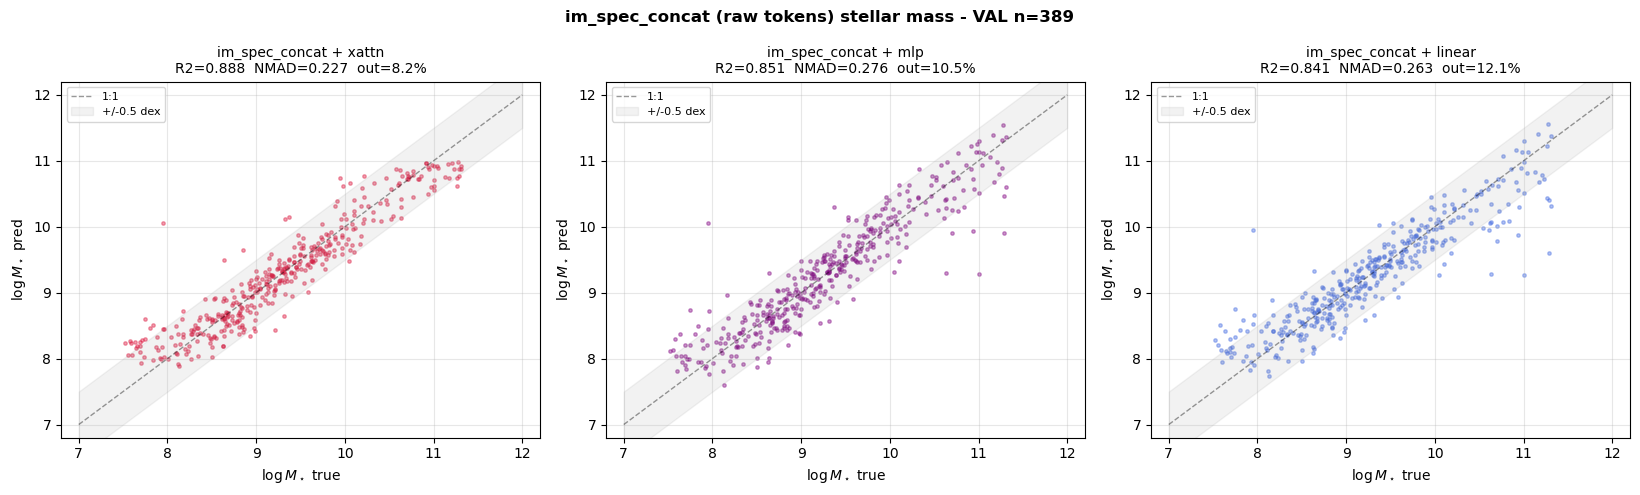

In [185]:
COLORS = {"xattn": "crimson", "mlp": "purple", "linear": "royalblue"}
results = {}   # head_kind -> dict(pred_test, best_val, best_epoch, metrics)
for head_kind in OPTIONS:
    r = train_head(head_kind); r["metrics"] = metrics(y[te], r["pred_test"])
    results[head_kind] = r
    show(f"im_spec_concat+{head_kind} (ep={r['best_epoch']})", r["metrics"])

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
for ax, head_kind in zip(axes, OPTIONS):
    plot_pred(ax, y[te], results[head_kind]["pred_test"], f"im_spec_concat + {head_kind}", COLORS[head_kind])
plt.suptitle(f"im_spec_concat (raw tokens) stellar mass - VAL n={len(te)}", fontweight="bold")
plt.tight_layout(); plt.show()

# Unimodal baselines — image-only & spectrum-only (raw patch tokens)

In [186]:
class UniHead(nn.Module):
    # Single-modality readout. tokens (B,T,dim) + valid mask (B,T). head in {linear, mlp, xattn}.
    def __init__(self, dim, head_kind="linear", d_model=D_MODEL, hidden=HIDDEN,
                 dropout=DROPOUT, n_heads=N_HEADS, use_stats=False):
        super().__init__()
        self.head_kind = head_kind
        self.use_stats = use_stats
        def _stats_proj(out_dim):
            m = nn.Linear(2, out_dim)
            nn.init.trunc_normal_(m.weight, std=0.02); nn.init.zeros_(m.bias)
            return m
        if head_kind in ("linear", "mlp"):
            self.ln = nn.LayerNorm(dim)
            if use_stats: self.stats_proj = _stats_proj(dim)
            self.head = (nn.Linear(dim, 1) if head_kind == "linear" else
                         nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(),
                                       nn.Dropout(dropout), nn.Linear(hidden, 1)))
        elif head_kind == "xattn":
            if use_stats: self.stats_proj = _stats_proj(d_model)
            self.proj = nn.Sequential(nn.Linear(dim, d_model), nn.LayerNorm(d_model))
            self.reg  = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
            self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
            self.norm = nn.LayerNorm(d_model)
            self.mlp  = nn.Sequential(nn.Linear(d_model, hidden), nn.ReLU(),
                                      nn.Dropout(dropout), nn.Linear(hidden, 1))
        else:
            raise ValueError(head_kind)

    def forward(self, tok, mask, stats=None):
        if self.head_kind in ("linear", "mlp"):
            vec = self.ln(_masked_mean(tok, mask))
            if self.use_stats and stats is not None: vec = vec + self.stats_proj(stats)
            return self.head(vec)
        x = self.proj(tok)
        out, _ = self.attn(self.reg.expand(tok.shape[0], -1, -1), x, x, key_padding_mask=~mask)
        vec = self.norm(out.squeeze(1))
        if self.use_stats and stats is not None: vec = vec + self.stats_proj(stats)
        return self.mlp(vec)


def _make_uni_ds(TOK, MASK, STATS):
    class DSU(Dataset):
        def __init__(self, p): self.p = p
        def __len__(self): return len(self.p)
        def __getitem__(self, i):
            j = self.p[i]
            t = torch.from_numpy(TOK[j])
            m = (torch.ones(t.shape[0], dtype=torch.bool) if MASK is None
                 else torch.from_numpy(MASK[j]))
            s = (torch.zeros(2, dtype=torch.float32) if STATS is None
                 else torch.from_numpy(STATS[j]))           # zeros placeholder when modality has no stat
            return t, m, s, torch.tensor(y[j], dtype=torch.float32)
    return DSU

@torch.no_grad()
def _eval_uni(model, loader, ysc):
    model.eval(); preds = []
    for tok, mask, st, _ in loader:
        preds.append(model(tok.to(DEVICE), mask.to(DEVICE), st.to(DEVICE)).cpu().numpy())
    return ysc.inverse_transform(np.concatenate(preds)).squeeze(1)

@torch.no_grad()
def _val_uni(model, loader, ym, ys):
    model.eval(); tot, n = 0.0, 0
    for tok, mask, st, yb in loader:
        yb = ((yb.to(DEVICE) - ym) / ys).unsqueeze(1)
        tot += nn.functional.mse_loss(model(tok.to(DEVICE), mask.to(DEVICE), st.to(DEVICE)), yb,
                                      reduction="sum").item(); n += len(yb)
    return tot / max(n, 1)

def train_uni(modality, head_kind, max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=FS_LR,
              wd=HEAD_WD, bs=BATCH_SIZE):
    if modality == "image":
        TOK, MASK, STATS = IMG_PATCH, None, IMG_STATS  # image: f150w brightness as the stat
    else:
        TOK, MASK, STATS = SPEC_TOK, SMASK, SPEC_STATS
    DSU = _make_uni_ds(TOK, MASK, STATS)
    tl = DataLoader(DSU(tr), batch_size=bs, shuffle=True)
    vl = DataLoader(DSU(va), batch_size=256, shuffle=False)
    el = DataLoader(DSU(te), batch_size=256, shuffle=False)

    torch.manual_seed(SEED)
    model = UniHead(TOK.shape[-1], head_kind, use_stats=(STATS is not None)).to(DEVICE)
    ysc = StandardScaler().fit(y[tr].reshape(-1, 1))
    ym, ysd = float(ysc.mean_[0]), float(ysc.scale_[0])
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_val, best_state, bad, best_ep = float("inf"), None, 0, 0
    pbar = tqdm(range(max_epochs), desc=f"{modality}+{head_kind}")
    for epoch in pbar:
        model.train()
        for tok, mask, st, yb in tl:
            yb = ((yb.to(DEVICE) - ym) / ysd).unsqueeze(1)
            opt.zero_grad()
            loss = nn.functional.mse_loss(model(tok.to(DEVICE), mask.to(DEVICE), st.to(DEVICE)), yb)
            loss.backward(); opt.step()
        vloss = _val_uni(model, vl, ym, ysd)
        pbar.set_postfix(val=f"{vloss:.4f}", best=f"{best_val:.4f}")
        if vloss < best_val - 1e-5:
            best_val, best_state, bad, best_ep = vloss, copy.deepcopy(model.state_dict()), 0, epoch
        else:
            bad += 1
            if bad >= patience: break
    pbar.close()
    if best_state is not None: model.load_state_dict(best_state)
    return dict(pred_test=_eval_uni(model, el, ysc), best_val=best_val, best_epoch=best_ep + 1)

## Run unimodal baselines (image patch / spectrum patch) for every head

In [187]:
results_uni = {}   # (modality, head) -> dict
for head_kind in HEADS:
    for modality in ("image", "spectrum"):
        r = train_uni(modality, head_kind); r["metrics"] = metrics(y[te], r["pred_test"])
        results_uni[(modality, head_kind)] = r
        show(f"{modality}-only+{head_kind} (ep={r['best_epoch']})", r["metrics"])

image+xattn:   0%|          | 0/300 [00:00<?, ?it/s]

image-only+xattn (ep=35)       R2=0.742  MAE=0.325  RMSE=0.452  NMAD=0.354  out=20.3%


spectrum+xattn:   0%|          | 0/300 [00:00<?, ?it/s]

spectrum-only+xattn (ep=79)    R2=0.837  MAE=0.273  RMSE=0.359  NMAD=0.323  out=14.1%


image+mlp:   0%|          | 0/300 [00:00<?, ?it/s]

...

spectrum-only+mlp (ep=90)      R2=0.793  MAE=0.297  RMSE=0.404  NMAD=0.334  out=14.4%


image+linear:   0%|          | 0/300 [00:00<?, ?it/s]

image-only+linear (ep=87)      R2=0.737  MAE=0.326  RMSE=0.456  NMAD=0.343  out=20.6%


spectrum+linear:   0%|          | 0/300 [00:00<?, ?it/s]

spectrum-only+linear (ep=283)  R2=0.752  MAE=0.329  RMSE=0.443  NMAD=0.376  out=19.3%


## Compare — unimodal vs im_spec_concat (raw tokens, trained)

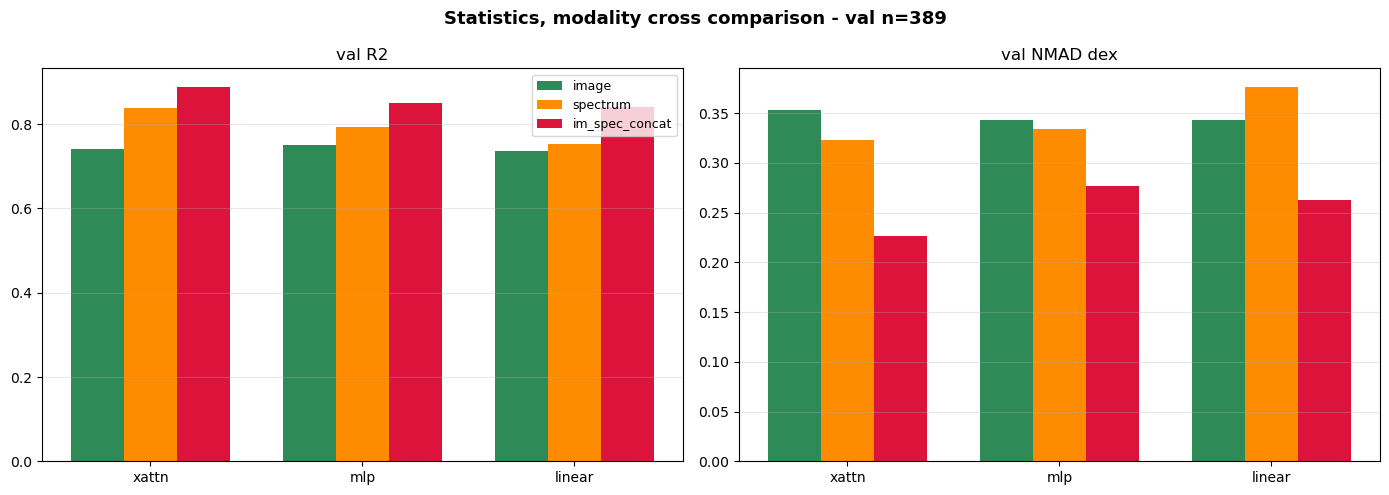

In [188]:
variants_uf = [("image", "seagreen"), ("spectrum", "darkorange"), ("im_spec_concat", "crimson")]
def _uf(name, head):
    return (results[head]["metrics"] if name == "im_spec_concat"
            else results_uni[(name, head)]["metrics"])

x = np.arange(len(HEADS)); w = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, ttl in [(axes[0], "r2", "val R2"),
                     (axes[1], "nmad", "val NMAD dex")]:
    for k, (name, col) in enumerate(variants_uf):
        ax.bar(x + (k - 1) * w, [_uf(name, h)[key] for h in HEADS], w, label=name, color=col)
    ax.set_xticks(x); ax.set_xticklabels(HEADS); ax.set_title(ttl); ax.grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=9)
plt.suptitle(f"Statistics, modality cross comparison - val n={len(te)}", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Zero-shot mass estimation (raw tokens, no training)

Pool each modality's raw tokens to a vector and run a distance-weighted **k-NN regressor**
(reference bank = train, query = val). image patch / spectrum patch / their concat.

In [189]:
ref = tr                       # kNN reference bank = train only (query = val; never include the query set)
def knn_zs(X, k=KNN_K):
    sc  = StandardScaler().fit(X[ref])
    knn = KNeighborsRegressor(n_neighbors=k, weights="distance").fit(sc.transform(X[ref]), y[ref])
    return knn.predict(sc.transform(X[te]))

def _np_masked_mean(x, m):
    w = m[..., None].astype(np.float32)
    return (x * w).sum(1) / np.clip(w.sum(1), 1.0, None)

IMG_PATCH_VEC = np.concatenate([IMG_PATCH.mean(1), IMG_STATS], -1)   # + f150w brightness
# Append the standardised abs-flux-scale stats to the spectrum feature (the kNN
# StandardScaler rescales all columns together, so the 2 extra dims are weighted
# consistently with the pooled-token dims).
SPEC_VEC      = np.concatenate([_np_masked_mean(SPEC_TOK, SMASK), SPEC_STATS], -1)
CONCAT_VEC    = np.concatenate([IMG_PATCH_VEC, SPEC_VEC], -1)

results_zs = {}
for name, X in [("zero-shot-image-patch", IMG_PATCH_VEC), ("zero-shot-spectrum-patch", SPEC_VEC),
                ("zero-shot-concat", CONCAT_VEC)]:
    pred = knn_zs(X)
    results_zs[name] = dict(pred_test=pred, metrics=metrics(y[te], pred))
    show(name, results_zs[name]["metrics"])

zero-shot-image-patch          R2=0.695  MAE=0.362  RMSE=0.491  NMAD=0.406  out=26.2%
zero-shot-spectrum-patch       R2=0.715  MAE=0.371  RMSE=0.475  NMAD=0.429  out=27.8%
zero-shot-concat               R2=0.772  MAE=0.308  RMSE=0.425  NMAD=0.350  out=20.1%


# CLIP head — trained fusion latent

Project the raw patch tokens through the trained `MultimodalFusion` projectors (attention pool
over patch tokens -> L2-normalized shared latent), then estimate mass on that latent three ways:
**zero-shot k-NN**, **MLP**, **linear**. (No cross-attention: the latent is two pooled vectors.)

In [190]:
from model.fusion import MultimodalFusion

def build_fusion():
    ck = torch.load(CKPT, map_location=DEVICE, weights_only=False)
    hp = ck["hyper_parameters"]
    in_dims = {"image": IMG_PATCH.shape[-1], "spectrum": SPEC_TOK.shape[-1]}
    fusion = MultimodalFusion(latent_dim=hp["latent_dim"], temperature=hp["temperature"])
    for name, cfg in hp["modalities"].items():
        fusion.register_modality(name, input_dim=in_dims[name], hidden_dim=cfg.get("hidden_dim"),
                                 pool=cfg.get("pool"), num_heads=cfg.get("num_heads", 4),
                                 stats_dim=cfg.get("stats_dim"))   # match ckpt arch (None for old ckpts)
    sd = {k[len("fusion."):]: v for k, v in ck["state_dict"].items() if k.startswith("fusion.")}
    fusion.load_state_dict(sd, strict=True)
    return fusion.to(DEVICE).eval(), hp

fusion, HP = build_fusion()
LATENT = fusion.latent_dim
print(f"loaded CLIP head: latent_dim={LATENT}  modalities={list(fusion.projectors.keys())}  "
      f"pools={ {n: HP['modalities'][n]['pool'] for n in HP['modalities']} }")

@torch.no_grad()
def clip_latents(bs=256):
    ei, es = [], []
    stats_mods = set(fusion.stats_encoders.keys())          # modalities the ckpt injects stats for
    _raw = {"spectrum": SPEC_STATS_RAW, "image": IMG_STATS_RAW}
    for s in tqdm(range(0, len(idx), bs), desc="clip latents"):
        sl = slice(s, s + bs)
        img  = torch.from_numpy(IMG_PATCH[sl]).to(DEVICE)
        spec = torch.from_numpy(SPEC_TOK[sl]).to(DEVICE)
        smask = torch.from_numpy(SMASK[sl]).to(DEVICE)
        avail = {n: torch.ones(img.shape[0], dtype=torch.bool, device=DEVICE) for n in ("image", "spectrum")}
        # fusion's StatsEncoder applies asinh+BN(+NaN impute) internally → feed RAW values
        # (NOT the pre-standardised *_STATS used by the raw-token heads above).
        stats = {m: torch.from_numpy(_raw[m][sl]).to(DEVICE) for m in stats_mods} or None
        emb = fusion({"image": img, "spectrum": spec}, avail, {"spectrum": smask}, stats)
        ei.append(emb["image"].cpu().numpy()); es.append(emb["spectrum"].cpu().numpy())
    return np.concatenate(ei), np.concatenate(es)

E_IMG, E_SPEC = clip_latents()
CLIP_FUSED = np.concatenate([E_IMG, E_SPEC], -1)       # (n, 2*LATENT)
print(f"clip latents: image={E_IMG.shape}  spectrum={E_SPEC.shape}  im_spec_concat={CLIP_FUSED.shape}")

loaded CLIP head: latent_dim=256  modalities=['image', 'spectrum']  pools={'image': 'attention', 'spectrum': 'attention'}


clip latents:   0%|          | 0/4 [00:00<?, ?it/s]

clip latents: image=(777, 256)  spectrum=(777, 256)  im_spec_concat=(777, 512)


In [191]:
class ClipHead(nn.Module):
    # Readout on the frozen CLIP latent concat (B, 2*LATENT). head in {linear, mlp}.
    def __init__(self, latent, head_kind="linear", hidden=HIDDEN, dropout=DROPOUT):
        super().__init__()
        self.head = (nn.Linear(2 * latent, 1) if head_kind == "linear" else
                     nn.Sequential(nn.Linear(2 * latent, hidden), nn.ReLU(),
                                   nn.Dropout(dropout), nn.Linear(hidden, 1)))
    def forward(self, x): return self.head(x)

def _make_feat_ds(FEAT):
    class DSF(Dataset):
        def __init__(self, p): self.p = p
        def __len__(self): return len(self.p)
        def __getitem__(self, i):
            j = self.p[i]
            return torch.from_numpy(FEAT[j]), torch.tensor(y[j], dtype=torch.float32)
    return DSF

@torch.no_grad()
def _eval_feat(model, loader, ysc):
    model.eval(); P = [model(x.to(DEVICE)).cpu().numpy() for x, _ in loader]
    return ysc.inverse_transform(np.concatenate(P)).squeeze(1)

@torch.no_grad()
def _val_feat(model, loader, ym, ys):
    model.eval(); tot, n = 0.0, 0
    for x, yb in loader:
        yb = ((yb.to(DEVICE) - ym) / ys).unsqueeze(1)
        tot += nn.functional.mse_loss(model(x.to(DEVICE)), yb, reduction="sum").item(); n += len(yb)
    return tot / max(n, 1)

def train_clip(head_kind, max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=FS_LR, wd=HEAD_WD, bs=BATCH_SIZE):
    DSF = _make_feat_ds(CLIP_FUSED)
    tl = DataLoader(DSF(tr), batch_size=bs, shuffle=True)
    vl = DataLoader(DSF(va), batch_size=256, shuffle=False)
    el = DataLoader(DSF(te), batch_size=256, shuffle=False)
    torch.manual_seed(SEED)
    model = ClipHead(LATENT, head_kind).to(DEVICE)
    ysc = StandardScaler().fit(y[tr].reshape(-1, 1))
    ym, ysd = float(ysc.mean_[0]), float(ysc.scale_[0])
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_val, best_state, bad, best_ep = float("inf"), None, 0, 0
    pbar = tqdm(range(max_epochs), desc=f"clip+{head_kind}")
    for epoch in pbar:
        model.train()
        for x, yb in tl:
            yb = ((yb.to(DEVICE) - ym) / ysd).unsqueeze(1)
            opt.zero_grad()
            loss = nn.functional.mse_loss(model(x.to(DEVICE)), yb); loss.backward(); opt.step()
        vloss = _val_feat(model, vl, ym, ysd)
        pbar.set_postfix(val=f"{vloss:.4f}", best=f"{best_val:.4f}")
        if vloss < best_val - 1e-5:
            best_val, best_state, bad, best_ep = vloss, copy.deepcopy(model.state_dict()), 0, epoch
        else:
            bad += 1
            if bad >= patience: break
    pbar.close()
    if best_state is not None: model.load_state_dict(best_state)
    return dict(pred_test=_eval_feat(model, el, ysc), best_val=best_val, best_epoch=best_ep + 1)


results_clip = {}
# Zero-shot k-NN on the clip latent (image / spectrum / im_spec_concat).
for name, X in [("clip-zero-shot-image", E_IMG), ("clip-zero-shot-spectrum", E_SPEC), ("clip-zero-shot-im_spec_concat", CLIP_FUSED)]:
    pred = knn_zs(X)
    results_clip[name] = dict(pred_test=pred, metrics=metrics(y[te], pred))
    show(name, results_clip[name]["metrics"])
# Trained linear / MLP on the frozen clip latent.
for head_kind in ("mlp", "linear"):
    r = train_clip(head_kind); r["metrics"] = metrics(y[te], r["pred_test"])
    results_clip[f"clip-{head_kind}"] = r
    show(f"clip-{head_kind} (ep={r['best_epoch']})", r["metrics"])

clip-zero-shot-image           R2=0.706  MAE=0.362  RMSE=0.483  NMAD=0.408  out=24.7%
clip-zero-shot-spectrum        R2=0.818  MAE=0.281  RMSE=0.379  NMAD=0.326  out=15.7%
clip-zero-shot-im_spec_concat  R2=0.843  MAE=0.260  RMSE=0.353  NMAD=0.322  out=11.8%


clip+mlp:   0%|          | 0/300 [00:00<?, ?it/s]

clip-mlp (ep=79)               R2=0.844  MAE=0.256  RMSE=0.351  NMAD=0.299  out=11.1%


clip+linear:   0%|          | 0/300 [00:00<?, ?it/s]

clip-linear (ep=297)           R2=0.795  MAE=0.302  RMSE=0.402  NMAD=0.355  out=17.2%


## CLIP-head group plot — zero-shot vs trained heads on the latent

/tmp/ipykernel_3228683/733927862.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(ttl); ax.grid(axis="y", alpha=0.3); ax.set_xticklabels(clip_order, rotation=30, ha="right")
/tmp/ipykernel_3228683/733927862.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(ttl); ax.grid(axis="y", alpha=0.3); ax.set_xticklabels(clip_order, rotation=30, ha="right")


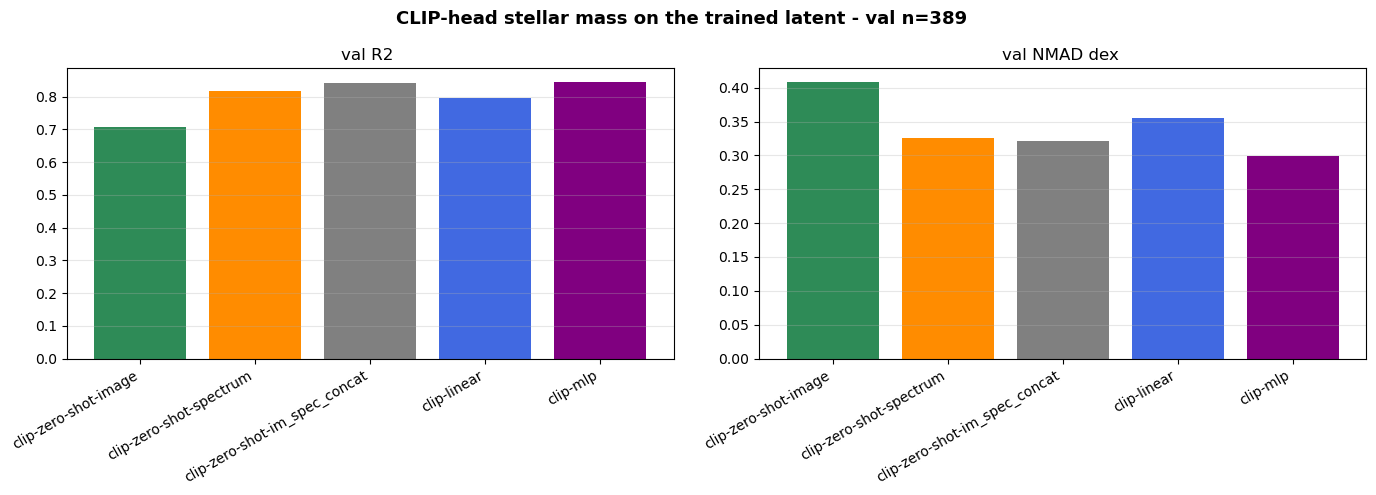

In [192]:
clip_order = ["clip-zero-shot-image", "clip-zero-shot-spectrum", "clip-zero-shot-im_spec_concat", "clip-linear", "clip-mlp"]
clip_cols  = ["seagreen", "darkorange", "gray", "royalblue", "purple"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, ttl in [(axes[0], "r2", "val R2 "),
                     (axes[1], "nmad", "val NMAD dex ")]:
    ax.bar(clip_order, [results_clip[n]["metrics"][key] for n in clip_order], color=clip_cols)
    ax.set_title(ttl); ax.grid(axis="y", alpha=0.3); ax.set_xticklabels(clip_order, rotation=30, ha="right")
plt.suptitle(f"CLIP-head stellar mass on the trained latent - val n={len(te)}",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Master comparison — all methods on the held-out test set

raw-token trained heads (im_spec_concat & unimodal), raw-token **zero-shot** k-NN, and the **CLIP-head**
latent (zero-shot + trained). Sorted by R2.

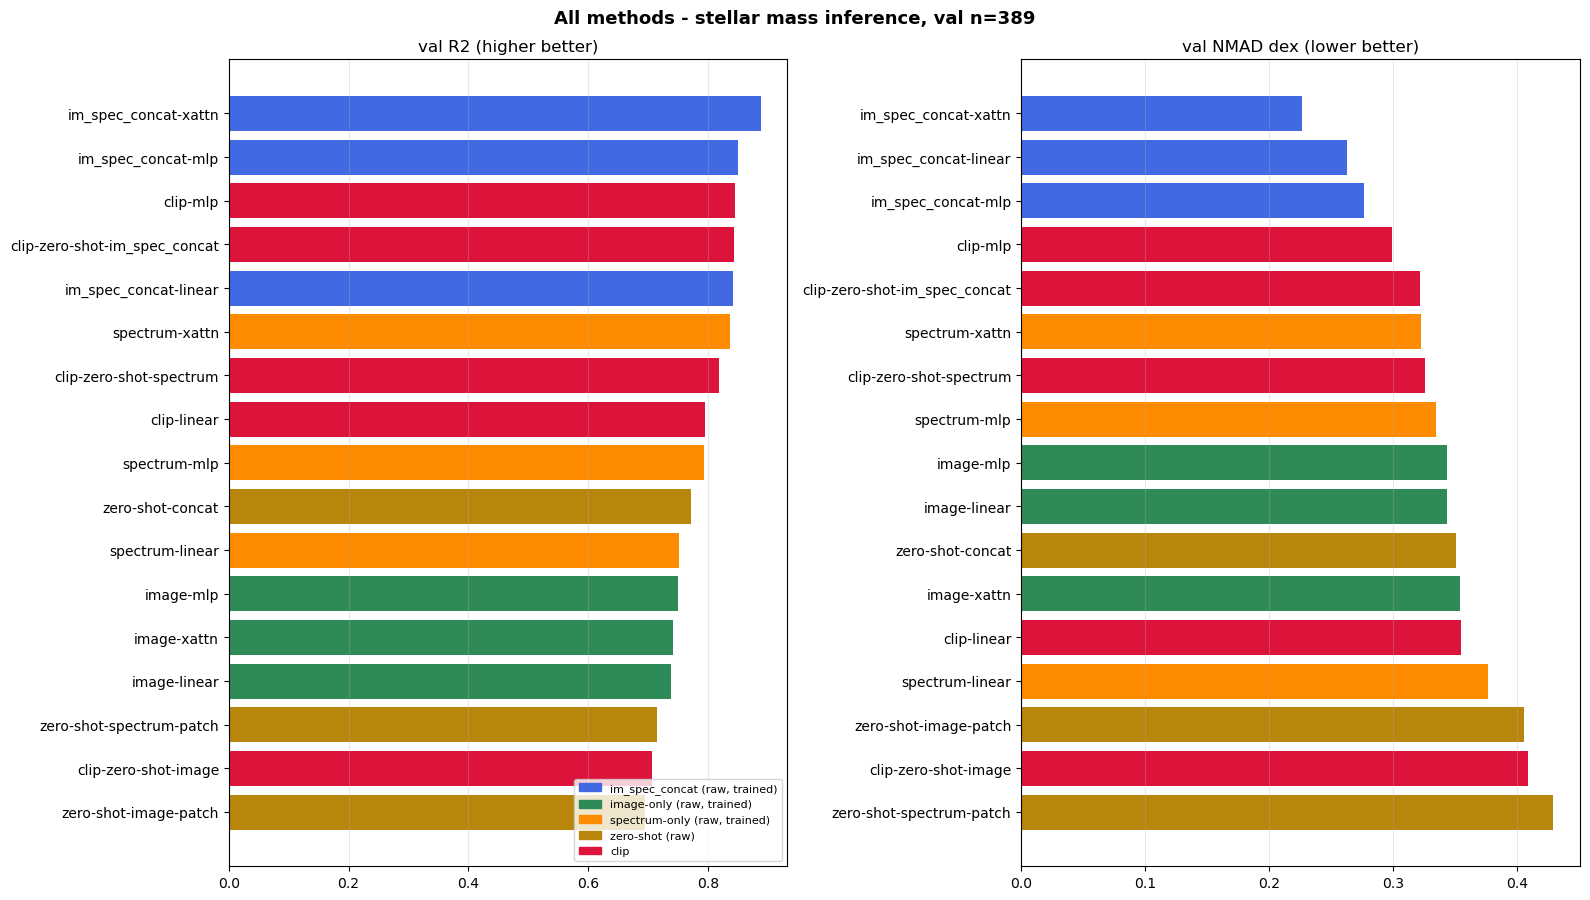

rank method                      R2    NMAD     out
----------------------------------------------------
   1 im_spec_concat-xattn     0.888   0.227   8.2%
   2 im_spec_concat-mlp       0.851   0.276  10.5%
   3 clip-mlp                 0.844   0.299  11.1%
   4 clip-zero-shot-im_spec_concat   0.843   0.322  11.8%
   5 im_spec_concat-linear    0.841   0.263  12.1%
   6 spectrum-xattn           0.837   0.323  14.1%
   7 clip-zero-shot-spectrum   0.818   0.326  15.7%
   8 clip-linear              0.795   0.355  17.2%
   9 spectrum-mlp             0.793   0.334  14.4%
  10 zero-shot-concat         0.772   0.350  20.1%
  11 spectrum-linear          0.752   0.376  19.3%
  12 image-mlp                0.751   0.343  18.5%
  13 image-xattn              0.742   0.354  20.3%
  14 image-linear             0.737   0.343  20.6%
  15 zero-shot-spectrum-patch   0.715   0.429  27.8%
  16 clip-zero-shot-image     0.706   0.408  24.7%
  17 zero-shot-image-patch    0.695   0.406  26.2%


In [193]:
all_m = {}
for hk, r in results.items():            all_m[f"im_spec_concat-{hk}"] = r["metrics"]
for (mod, hk), r in results_uni.items(): all_m[f"{mod}-{hk}"] = r["metrics"]
for k, r in results_zs.items():          all_m[k] = r["metrics"]
for k, r in results_clip.items():        all_m[k] = r["metrics"]

def _family(n):
    if n.startswith("clip"):     return ("clip", "crimson")
    if n.startswith("zero-shot-"):      return ("zero-shot (raw)", "darkgoldenrod")
    if n.startswith("im_spec_concat"):    return ("im_spec_concat (raw, trained)", "royalblue")
    if n.startswith("image"):    return ("image-only (raw, trained)", "seagreen")
    if n.startswith("spectrum"): return ("spectrum-only (raw, trained)", "darkorange")
    return ("other", "gray")

fig, axes = plt.subplots(1, 2, figsize=(16, 0.42 * len(all_m) + 2))
for ax, key, rev in [(axes[0], "r2", False), (axes[1], "nmad", True)]:
    order = sorted(all_m, key=lambda n: all_m[n][key], reverse=rev)
    ax.barh(order, [all_m[n][key] for n in order], color=[_family(n)[1] for n in order])
    ax.set_title("val R2 (higher better)" if key == "r2" else "val NMAD dex (lower better)")
    ax.grid(axis="x", alpha=0.3)
from matplotlib.patches import Patch
seen = {}
for n in all_m: fam, col = _family(n); seen[fam] = col
axes[0].legend(handles=[Patch(color=c, label=f) for f, c in seen.items()], fontsize=8, loc="lower right")
plt.suptitle(f"All methods - stellar mass inference, val n={len(te)}", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"{'rank':4s} {'method':22s} {'R2':>7s} {'NMAD':>7s} {'out':>7s}")
print("-" * 52)
for i, n in enumerate(sorted(all_m, key=lambda n: -all_m[n]["r2"]), 1):
    m = all_m[n]
    print(f"{i:4d} {n:22s} {m['r2']:7.3f} {m['nmad']:7.3f} {m['out']:6.1%}")

# Prediction vs true mass — per group

Pred-vs-true scatter (same style as the earlier panels), grouped by method family, all on the
held-out test set.

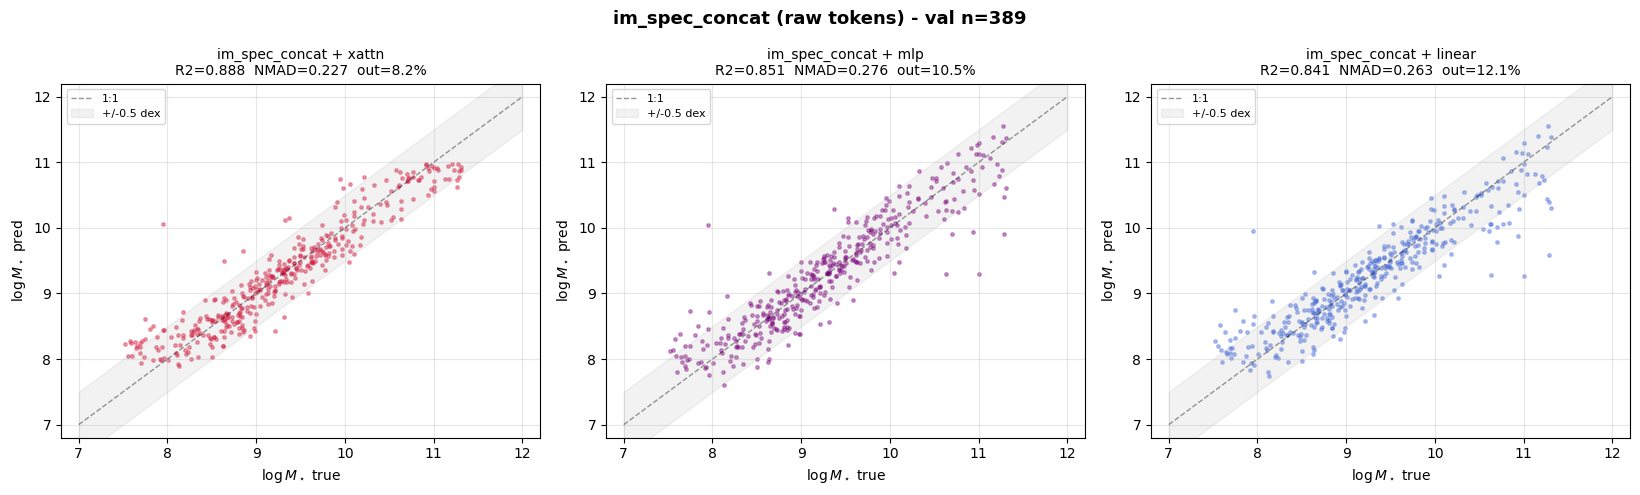

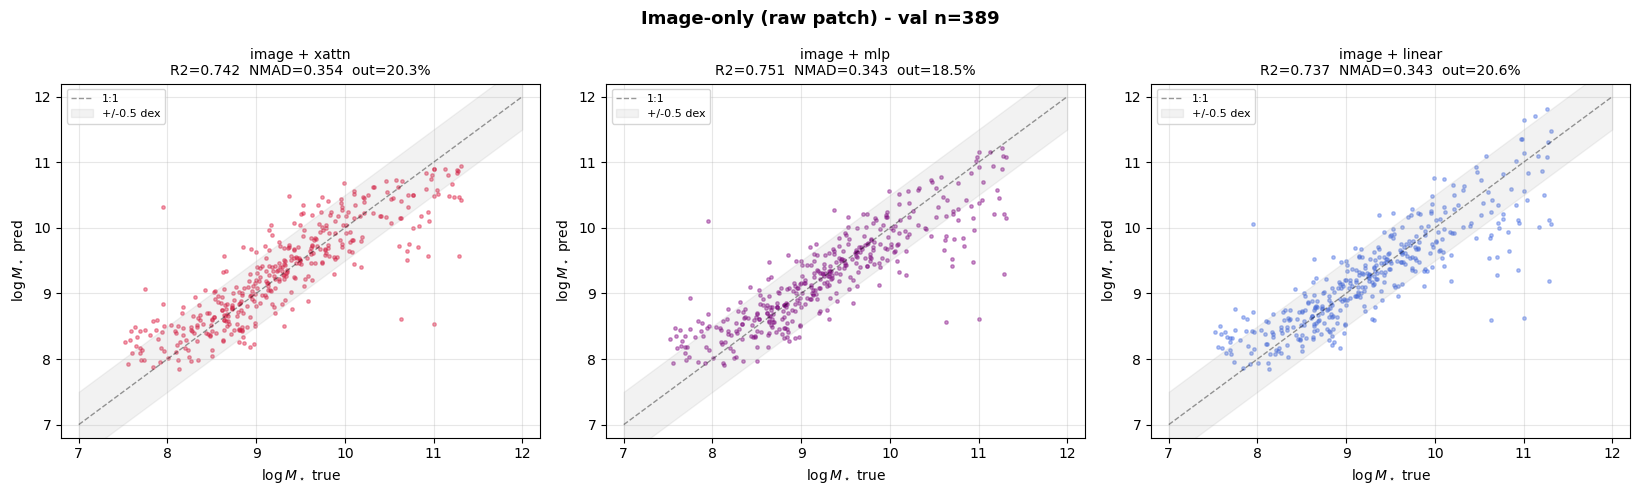

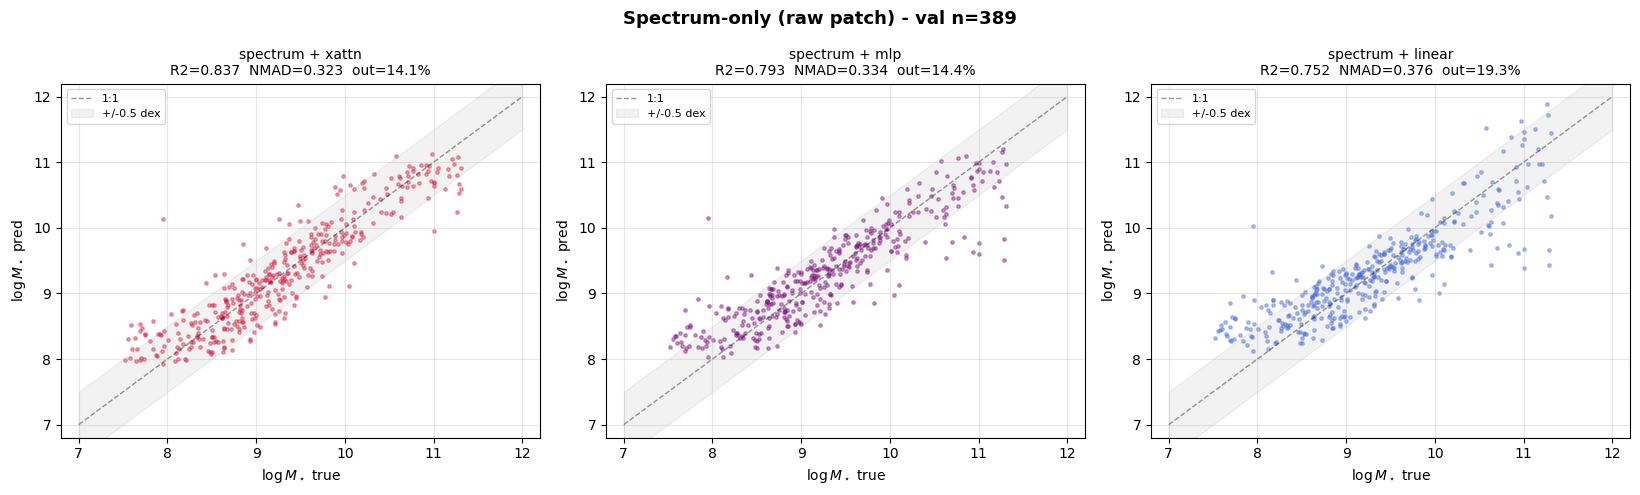

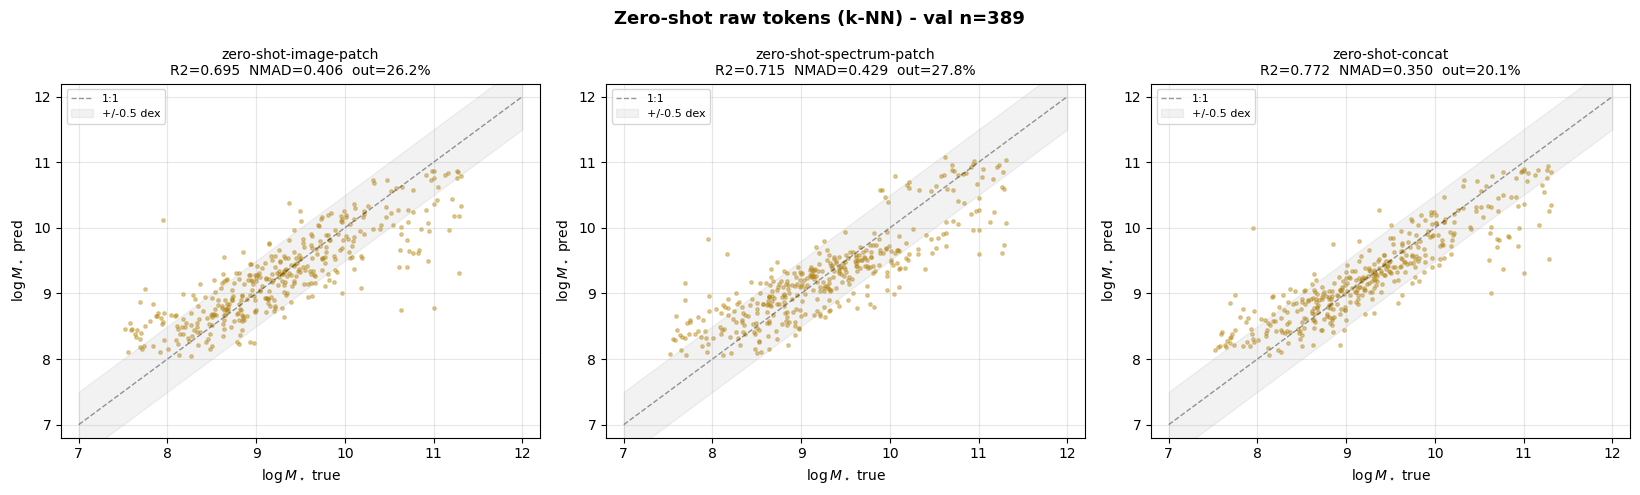

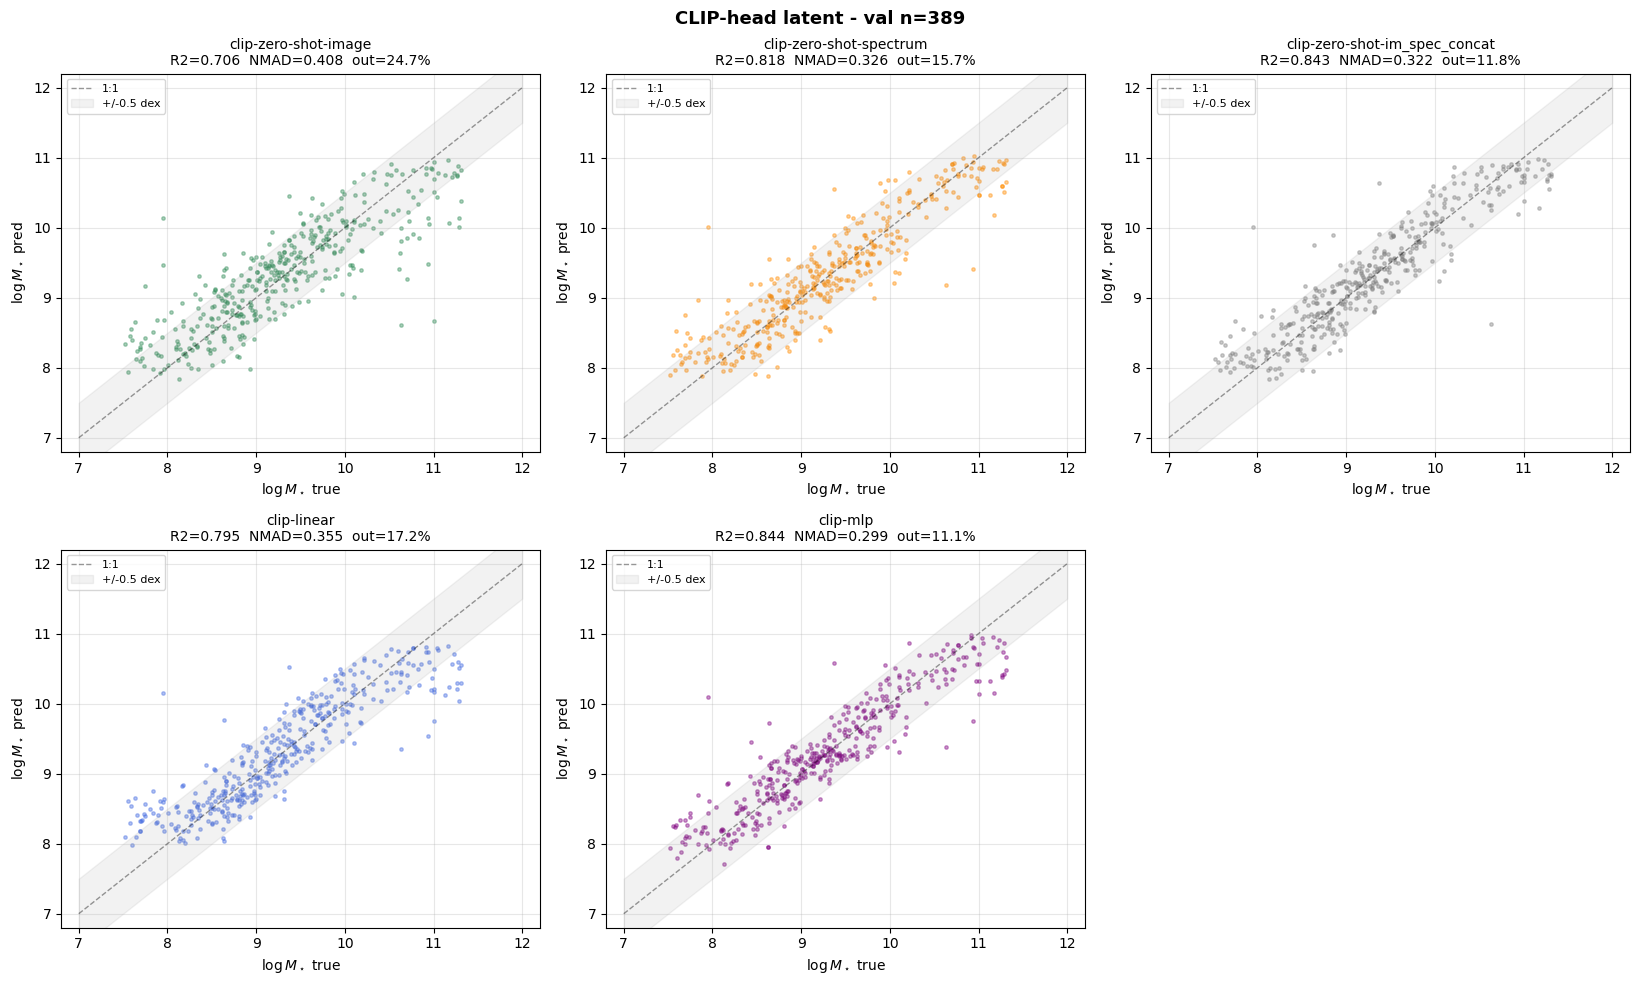

In [194]:
def grid_pred(items, suptitle, ncols=None):
    # items: list of (title, pred, color)
    n = len(items); ncols = ncols or n; nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (title, pred, col) in zip(axes, items):
        plot_pred(ax, y[te], pred, title, col)
    for ax in axes[len(items):]:
        ax.axis("off")
    fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

# im_spec_concat (raw tokens, trained)
grid_pred([(f"im_spec_concat + {h}", results[h]["pred_test"], COLORS[h]) for h in OPTIONS],
          f"im_spec_concat (raw tokens) - val n={len(te)}")

# Image-only (raw patch, trained)
grid_pred([(f"image + {h}", results_uni[("image", h)]["pred_test"], COLORS[h]) for h in HEADS],
          f"Image-only (raw patch) - val n={len(te)}")

# Spectrum-only (raw patch, trained)
grid_pred([(f"spectrum + {h}", results_uni[("spectrum", h)]["pred_test"], COLORS[h]) for h in HEADS],
          f"Spectrum-only (raw patch) - val n={len(te)}")

# Zero-shot (raw tokens, k-NN)
grid_pred([(n, results_zs[n]["pred_test"], "darkgoldenrod") for n in
           ["zero-shot-image-patch", "zero-shot-spectrum-patch", "zero-shot-concat"]],
          f"Zero-shot raw tokens (k-NN) - val n={len(te)}")

# CLIP head (latent: zero-shot + trained)
_clip_cols = {"clip-zero-shot-image": "seagreen", "clip-zero-shot-spectrum": "darkorange",
              "clip-zero-shot-im_spec_concat": "gray", "clip-linear": "royalblue", "clip-mlp": "purple"}
grid_pred([(n, results_clip[n]["pred_test"], _clip_cols[n]) for n in
           ["clip-zero-shot-image", "clip-zero-shot-spectrum", "clip-zero-shot-im_spec_concat", "clip-linear", "clip-mlp"]],
          f"CLIP-head latent - val n={len(te)}", ncols=3)

# (a) Residual vs true mass — diagnosing the low-mass end

Residual `pred − true` against true `logM`, **coloured by spectrum S/N (sn50)**. The low-mass
end is over-predicted because faint = low-S/N spectra carry little mass signal, so the MSE-optimal
model shrinks toward the training mean (regression to the mean). The red running-median line shows
the bias; it crosses zero near the train mean (dashed line).

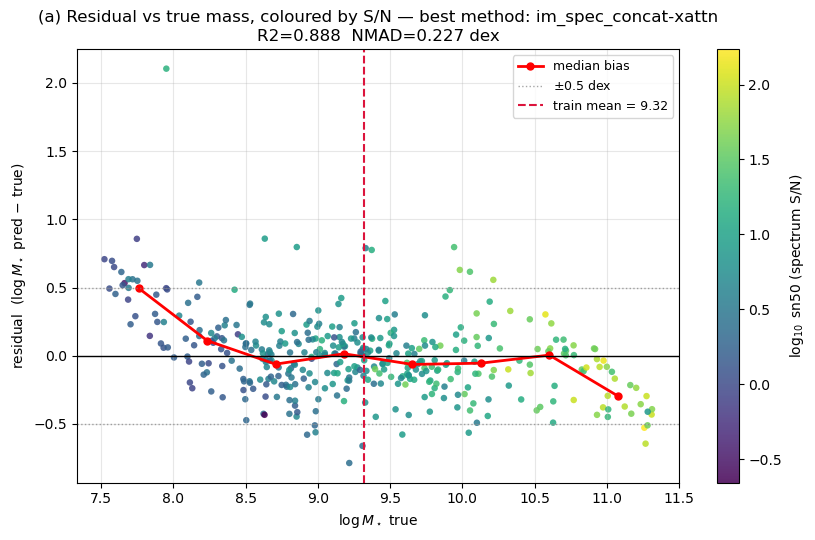

best method: im_spec_concat-xattn
logM bin          n    bias  scatter  med sn50
[7.52,8.00)   29   +0.51     0.36       1.3
[8.00,8.47)   38   +0.09     0.20       1.6
[8.47,8.94)   82   -0.05     0.25       3.2
[8.94,9.42)   81   -0.02     0.25       5.8
[9.42,9.89)   68   -0.05     0.19       9.3
[9.89,10.37)   39   +0.00     0.33      18.3
[10.37,10.84)   25   -0.06     0.21      32.3
[10.84,11.31)   26   -0.27     0.19      55.9


In [195]:
# Gather every method's val predictions, pick the best by R2, plot its residuals coloured by S/N.
all_pred = {}
for hk, r in results.items():            all_pred[f"im_spec_concat-{hk}"] = r["pred_test"]
for (mod, hk), r in results_uni.items(): all_pred[f"{mod}-{hk}"]          = r["pred_test"]
for k, r in results_zs.items():          all_pred[k]                      = r["pred_test"]
for k, r in results_clip.items():        all_pred[k]                      = r["pred_test"]

best  = max(all_pred, key=lambda n: metrics(y[te], all_pred[n])["r2"])
pred  = all_pred[best]
yt    = y[te]
resid = pred - yt
sn_te = sn50[idx][te]                                    # spectrum S/N for the plotted points

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sc = ax.scatter(yt, resid, c=np.log10(sn_te), cmap="viridis", s=22, alpha=0.85,
                edgecolors="none", rasterized=True)
cb = fig.colorbar(sc, ax=ax); cb.set_label(r"$\log_{10}$ sn50 (spectrum S/N)")

# running median bias in logM bins -> shows the regression-to-mean trend
bins = np.linspace(yt.min(), yt.max(), 9)
bc   = 0.5 * (bins[:-1] + bins[1:])
med  = np.array([np.median(resid[(yt >= bins[i]) & (yt < bins[i + 1])])
                 if ((yt >= bins[i]) & (yt < bins[i + 1])).any() else np.nan
                 for i in range(len(bins) - 1)])
ax.plot(bc, med, "r-o", lw=2, ms=5, label="median bias")
ax.axhline(0, color="k", lw=1)
ax.axhline( 0.5, color="gray", ls=":", lw=1, alpha=0.7)
ax.axhline(-0.5, color="gray", ls=":", lw=1, alpha=0.7, label=r"$\pm0.5$ dex")
ax.axvline(y[tr].mean(), color="crimson", ls="--", lw=1.5, label=f"train mean = {y[tr].mean():.2f}")

ax.set_xlabel(r"$\log M_\star$ true"); ax.set_ylabel(r"residual  ($\log M_\star$ pred $-$ true)")
ax.set_title(f"(a) Residual vs true mass, coloured by S/N — best method: {best}\n"
             f"R2={metrics(yt, pred)['r2']:.3f}  NMAD={metrics(yt, pred)['nmad']:.3f} dex")
ax.legend(fontsize=9, loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Quick numeric readout: bias + median S/N per mass bin (the over-prediction at the low end).
print(f"best method: {best}")
print(f"{'logM bin':14s} {'n':>4s} {'bias':>7s} {'scatter':>8s} {'med sn50':>9s}")
for i in range(len(bins) - 1):
    m = (yt >= bins[i]) & (yt < bins[i + 1])
    if m.sum() == 0: continue
    d = resid[m]
    print(f"[{bins[i]:.2f},{bins[i+1]:.2f}) {m.sum():>4d} {d.mean():>+7.2f} "
          f"{d.std():>8.2f} {np.median(sn_te[m]):>9.1f}")

# Comparison with AstroCLIP — stellar mass M* only

Reference numbers are the **M\* column** of the AstroCLIP table (Parker et al. 2024); those are
**R2** only. Our methods use the **MLP** readout of each inference and report **R2 + sigma_NMAD**:
image-only -> *Images* block, spectrum-only -> *Spectra* block, and the two fused readouts
(im_spec_concat raw tokens & CLIP latent) -> a new *Image+Spectrum* block that the reference lacks.

In [196]:
# === Aligned (CLIP latent) single-modality few-shot: MLP on E_IMG / E_SPEC alone ===
# train_clip only fit the FUSED concat; this adds the image-only & spectrum-only aligned
# few-shot rows so the comparison table matches the reference (AstroCLIP) layout.
def train_feat_mlp(FEAT, head_kind="mlp", max_epochs=MAX_EPOCHS, patience=PATIENCE,
                   lr=FS_LR, wd=HEAD_WD, bs=BATCH_SIZE, hidden=HIDDEN, dropout=DROPOUT):
    in_dim = FEAT.shape[-1]
    DSF = _make_feat_ds(FEAT)
    tl = DataLoader(DSF(tr), batch_size=bs, shuffle=True)
    vl = DataLoader(DSF(va), batch_size=256, shuffle=False)
    el = DataLoader(DSF(te), batch_size=256, shuffle=False)
    torch.manual_seed(SEED)
    model = (nn.Linear(in_dim, 1) if head_kind == "linear" else
             nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                           nn.Dropout(dropout), nn.Linear(hidden, 1))).to(DEVICE)
    ysc = StandardScaler().fit(y[tr].reshape(-1, 1))
    ym, ysd = float(ysc.mean_[0]), float(ysc.scale_[0])
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_val, best_state, bad, best_ep = float("inf"), None, 0, 0
    pbar = tqdm(range(max_epochs), desc=f"clip-1mod+{head_kind}")
    for epoch in pbar:
        model.train()
        for x, yb in tl:
            yb = ((yb.to(DEVICE) - ym) / ysd).unsqueeze(1)
            opt.zero_grad()
            loss = nn.functional.mse_loss(model(x.to(DEVICE)), yb); loss.backward(); opt.step()
        vloss = _val_feat(model, vl, ym, ysd)
        pbar.set_postfix(val=f"{vloss:.4f}", best=f"{best_val:.4f}")
        if vloss < best_val - 1e-5:
            best_val, best_state, bad, best_ep = vloss, copy.deepcopy(model.state_dict()), 0, epoch
        else:
            bad += 1
            if bad >= patience: break
    pbar.close()
    if best_state is not None: model.load_state_dict(best_state)
    return dict(pred_test=_eval_feat(model, el, ysc), best_val=best_val, best_epoch=best_ep + 1)

for mod, FEAT in [("image", E_IMG), ("spectrum", E_SPEC)]:
    r = train_feat_mlp(FEAT, "mlp"); r["metrics"] = metrics(y[te], r["pred_test"])
    results_clip[f"clip-{mod}-mlp"] = r
    show(f"clip-{mod}-mlp (aligned few-shot, ep={r['best_epoch']})", r["metrics"])


clip-1mod+mlp:   0%|          | 0/300 [00:00<?, ?it/s]

clip-image-mlp (aligned few-shot, ep=123) R2=0.731  MAE=0.345  RMSE=0.461  NMAD=0.420  out=21.9%


clip-1mod+mlp:   0%|          | 0/300 [00:00<?, ?it/s]

clip-spectrum-mlp (aligned few-shot, ep=109) R2=0.822  MAE=0.275  RMSE=0.375  NMAD=0.302  out=15.4%


In [ ]:
# === AstroCLIP M* comparison: reference (R2) + our unaligned (raw) & aligned (CLIP) readouts ===
# Mapping to the reference table: our raw-token results == "Unaligned Trans.",
# our CLIP-latent results == "AstroCLIP" (aligned). zero-shot = kNN, few-shot = MLP or x-attn.
# (aligned/CLIP latent is two pooled vectors -> no cross-attention, MLP only.)
ref_mstar = [   # (modality, method, R2)  -- M* column of the AstroCLIP table
    ("Images",  "AstroCLIP Zero-Shot",        0.74),
    ("Images",  "AstroCLIP Few-Shot",         0.73),
    ("Images",  "Unaligned Trans. Zero-Shot", 0.65),
    ("Images",  "Unaligned Trans. Few-Shot",  0.72),
    ("Images",  "Stein et al. Zero-Shot",     0.43),
    ("Images",  "Stein et al. Few-Shot",      0.48),
    ("Images",  "ResNet18",                   0.72),
    ("Spectra", "AstroCLIP Zero-Shot",        0.87),
    ("Spectra", "AstroCLIP Few-Shot",         0.88),
    ("Spectra", "Unaligned Trans. Zero-Shot", 0.84),
    ("Spectra", "Unaligned Trans. Few-Shot",  0.88),
]
ours_mstar = [  # (modality, method, metrics-dict)
    # --- Images ---
    ("Images",         "This work: image, unaligned (zero-shot)",          results_zs["zero-shot-image-patch"]["metrics"]),
    ("Images",         "This work: image, unaligned (few-shot, MLP)",      results_uni[("image", "mlp")]["metrics"]),
    ("Images",         "This work: image, unaligned (few-shot, x-attn)",   results_uni[("image", "xattn")]["metrics"]),
    ("Images",         "This work: image, aligned/CLIP (zero-shot)",       results_clip["clip-zero-shot-image"]["metrics"]),
    ("Images",         "This work: image, aligned/CLIP (few-shot, MLP)",   results_clip["clip-image-mlp"]["metrics"]),
    # --- Spectra ---
    ("Spectra",        "This work: spectrum, unaligned (zero-shot)",        results_zs["zero-shot-spectrum-patch"]["metrics"]),
    ("Spectra",        "This work: spectrum, unaligned (few-shot, MLP)",    results_uni[("spectrum", "mlp")]["metrics"]),
    ("Spectra",        "This work: spectrum, unaligned (few-shot, x-attn)", results_uni[("spectrum", "xattn")]["metrics"]),
    ("Spectra",        "This work: spectrum, aligned/CLIP (zero-shot)",     results_clip["clip-zero-shot-spectrum"]["metrics"]),
    ("Spectra",        "This work: spectrum, aligned/CLIP (few-shot, MLP)", results_clip["clip-spectrum-mlp"]["metrics"]),
    # --- Image + Spectrum (not in the reference table) ---
    ("Image+Spectrum", "This work: im_spec_concat, unaligned (zero-shot)",        results_zs["zero-shot-concat"]["metrics"]),
    ("Image+Spectrum", "This work: im_spec_concat, unaligned (few-shot, MLP)",    results["mlp"]["metrics"]),
    ("Image+Spectrum", "This work: im_spec_concat, unaligned (few-shot, x-attn)", results["xattn"]["metrics"]),
    ("Image+Spectrum", "This work: CLIP latent, aligned (zero-shot)",             results_clip["clip-zero-shot-im_spec_concat"]["metrics"]),
    ("Image+Spectrum", "This work: CLIP latent, aligned (few-shot, MLP)",         results_clip["clip-mlp"]["metrics"]),
]

W = 58
print(f"{'Source / Method':{W}s} {'R2':>6s} {'sigma_NMAD':>11s}")
for g in ("Images", "Spectra", "Image+Spectrum"):
    print(f"\n== {g} ==")
    for mod, name, r2 in ref_mstar:
        if mod == g:
            print(f"{name:{W}s} {r2:6.2f} {'-':>11s}")
    for mod, name, m in ours_mstar:
        if mod == g:
            print(f"{name:{W}s} {m['r2']:6.2f} {m['nmad']:11.3f}")


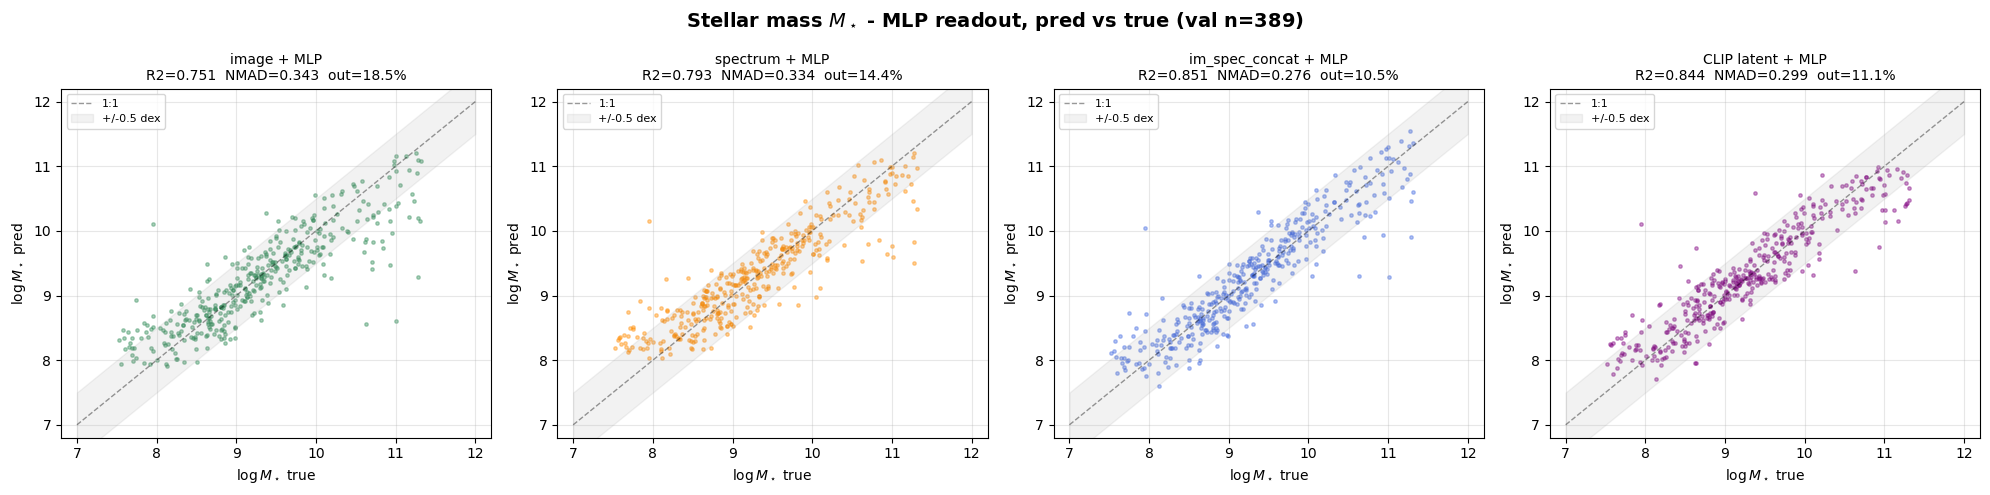

In [198]:
# === pred vs true for the selected MLP readouts (the rows of the comparison table) ===
sel_methods = [
    ("image + MLP",          results_uni[("image", "mlp")]["pred_test"],    "seagreen"),
    ("spectrum + MLP",       results_uni[("spectrum", "mlp")]["pred_test"], "darkorange"),
    ("im_spec_concat + MLP", results["mlp"]["pred_test"],                   "royalblue"),
    ("CLIP latent + MLP",    results_clip["clip-mlp"]["pred_test"],         "purple"),
]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, pred, col) in zip(axes, sel_methods):
    plot_pred(ax, y[te], pred, title, col)
fig.suptitle(f"Stellar mass $M_\\star$ - MLP readout, pred vs true (val n={len(te)})",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
